# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head()

In [ ]:
# información general
df.info()


## Revisión general de datos:
- Los datos no tienen valores nulos.
- La columna 'date' tiene formato 'object' y debería de ser de fecha, por lo que se hará la corrección del formato.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df['user_id'].nunique()

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors='coerce') # Se cambia el formato de la columna a fecha. 
df["date"].describe()

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
# Sólo considerando las que tienen monto superior a cero, que son las que convirtieron. 
print(df.loc[df['gasto'] > 0, 'gasto'].describe())
print(df['gasto'].describe()) # Sólo para verlo en general. 

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
print(df['converted'].describe())
print(df['converted'].value_counts(normalize=True)*100)

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print("\nConteo de categorías:")
    print(f"Columna {col}") #completa el código
    print(df[col].value_counts(normalize=True)*100)
    print()


    - Todas las columnas categóricas tienen valores esperados.


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:
# Gasto por versión
gasto_A = df.loc[(df['landing'] == 'A') & (df['converted'] == 1), 'gasto'] #completa el código
gasto_B = df.loc[(df['landing'] == 'B') & (df['converted'] == 1), 'gasto'] #completa el código

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

### Prueba t de Student

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio de los clientes es igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de los clientes es diferente en la página A y en la página B. En promedio, B genera 7.66 más por usuario convertido.  

In [ ]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico t: {t_stat}")
print(f"Valor p: {p_value}")

print(f"Gasto promedio versión A: {gasto_A.mean()}")
print(f"Gasto promedio versión B: {gasto_B.mean()}")
diferencia = gasto_A.mean() - gasto_B.mean()
diferencia

### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p es significativamente menor que α = 0.05, se rechaza la hipótesis nula de igualdad de medias.

**Interpretación de negocio:**  
Existe evidencia estadística significativa de que el gasto promedio difiere entre ambas versiones. En particular, la versión B presenta un gasto promedio mayor que la versión A. Antes de tomar decisiones estratégicas, se recomienda evaluar la magnitud práctica de la diferencia, pues si bien hay una diferencia estadísticamente significativa, no sabemos aún si es económicamente significativa. 


---


## 4📈.  Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es igual en la página A y la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente en la página A y la página B.

In [ ]:
# Número de usuarios convertidos por página
df_filtrado = df[df['converted'] == 1]
conversiones_1 = df_filtrado.groupby('landing')['converted'].count()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones_1)
print("\nTotal de usuarios por página:\n", totales)


In [ ]:
# Calcular tasa de conversión y dirección. 
tasa_A = conversiones_1['A'] / totales['A']
tasa_B = conversiones_1['B'] / totales['B']
print(f"Tasa de conversión A: {tasa_A: .2%}")
print(f"Tasa de conversión B {tasa_B: .2%}")
diferencia_tasa_A_B = (tasa_A - tasa_B) * 100
diferencia_tasa_A_B

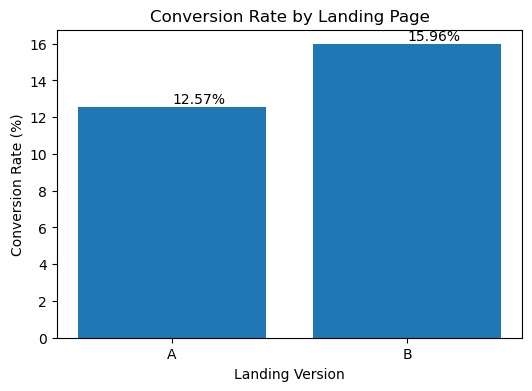

In [17]:
import matplotlib.pyplot as plt

landing = ['A', 'B']
conversion = [12.57, 15.96]

plt.figure(figsize=(6,4))
plt.bar(landing, conversion)

plt.title('Conversion Rate by Landing Page')
plt.xlabel('Landing Version')
plt.ylabel('Conversion Rate (%)')

for i, value in enumerate(conversion):
    plt.text(i, value + 0.2, f'{value:.2f}%')

plt.show()

In [55]:
# Aplicar prueba

z_stat, p_value = proportions_ztest(conversiones_1, totales)

# Visualizar resultados
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula de igualdad en las tasas de conversión. 

**Interpretación de negocio:**  
Existe evidencia estadística significativa de que la tasa de conversión difiere entre ambas versiones. La versión B (15.96%) presenta una mayor tasa de conversión que la versión A (12.57%). De igual manera, se señala la existencia de una diferencia estadísticamente significativa, pero no se sabe aún si es económicamente significativa. 

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba chi cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay evidencia de asociación entre las variables. 
- **Hipótesis alternativa (H₁):** Sí hay evidencia de asociación entre las variables. 

In [56]:


# Tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)
tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') *100
tabla_normalizada


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


In [57]:

# Aplicar prueba
chi2_contingency(tabla)



Chi2ContingencyResult(statistic=8.662108841397938, pvalue=0.0341375947833914, dof=3, expected_freq=array([[10232.47225,  1702.52775],
       [ 5249.55405,   873.44595],
       [15421.15445,  2565.84555],
       [ 3390.81925,   564.18075]]))

### 📝 Conclusión e interpretación


**Decisión:**  
Se rechaza la hipótesis nula, pues hay evidencia de asociación entre las variables. 

**Interpretación de negocio:**  
Existe evidencia estadística de asociación entre la fuente de tráfico y la conversión (p < 0.05). Sin embargo, las diferencias en tasas de conversión entre canales son relativamente pequeñas. Por tanto, antes de tomar decisiones estratégicas, se recomienda evaluar el volumen de tráfico y el impacto absoluto en conversiones por canal para determinar relevancia económica.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi cuadrada (Podría funcionar una prueba z)

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay relación entre 'user_type' y 'converted'
- **Hipótesis alternativa (H₁):** Sí hay relación entre 'user_type' y 'converted'

In [58]:

# Tabla de contingencia
tabla2 = pd.crosstab(df['user_type'], df['converted'])
print(tabla)
tabla_normalizada2 = pd.crosstab(df['user_type'], df['converted'], normalize='index') *100
tabla_normalizada2

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


In [59]:

# Aplicar prueba
chi2_contingency(tabla2)


Chi2ContingencyResult(statistic=0.5134849494478645, pvalue=0.4736341272301974, dof=1, expected_freq=array([[22319.39255,  3713.60745],
       [11974.60745,  1992.39255]]))

### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula. 

**Interpretación de negocio:**  
No se encontró evidencia estadísticamente significativa de asociación entre el tipo de usuario (nuevo o recurrente) y la conversión. Las tasas de conversión son prácticamente iguales entre ambos grupos (≈14%), lo que sugiere que el comportamiento de conversión es similar independientemente del tipo de usuario.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

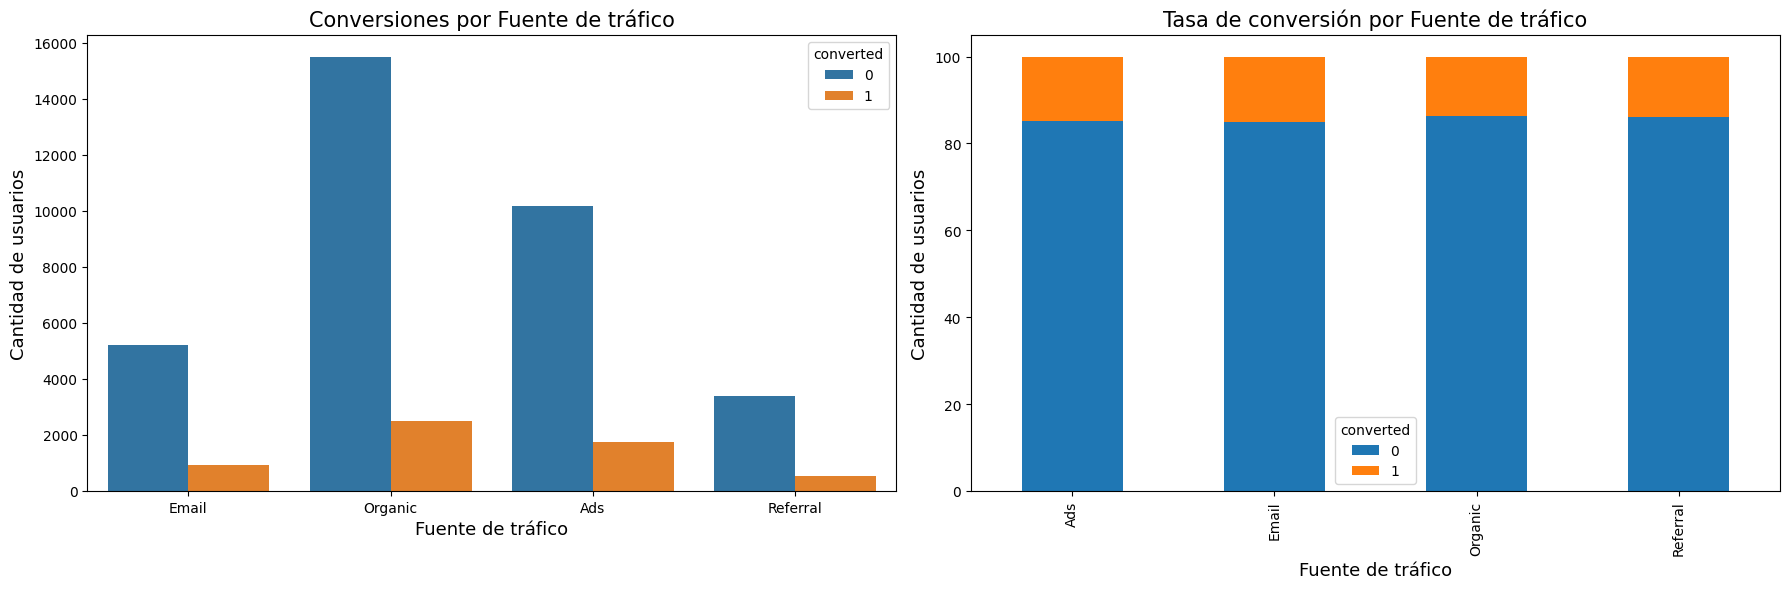

In [60]:
# Cantidad absoluta de usuarios que convirtieron y no convirtieron (Barras agrupadas)
fig, axes = plt.subplots(1, 2, figsize=(18,6))
# Barras agrupadas
sns.countplot(data=df, x='traffic_source', hue='converted', ax=axes[0])
axes[0].set_title("Conversiones por Fuente de tráfico", fontsize=15)
axes[0].set_xlabel("Fuente de tráfico", fontsize=13)
axes[0].set_ylabel("Cantidad de usuarios", fontsize=13)

# Barras apiladas
tabla_normalizada.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Tasa de conversión por Fuente de tráfico', fontsize=15)
axes[1].set_xlabel("Fuente de tráfico", fontsize=13)
axes[1].set_ylabel("Cantidad de usuarios", fontsize=13)

plt.tight_layout()
plt.show()

✍️ **Comentario**:
Aunque existe evidencia estadística de asociación entre la fuente de tráfico y la conversión, las diferencias en tasas son pequeñas. Organic genera el mayor número de conversiones principalmente por su volumen de tráfico, no por una tasa de conversión sustancialmente superior, pues éstas son muy similares, fluctuando entre 13.8% y 15%.

### Relación entre el tipo de usuario y la conversión

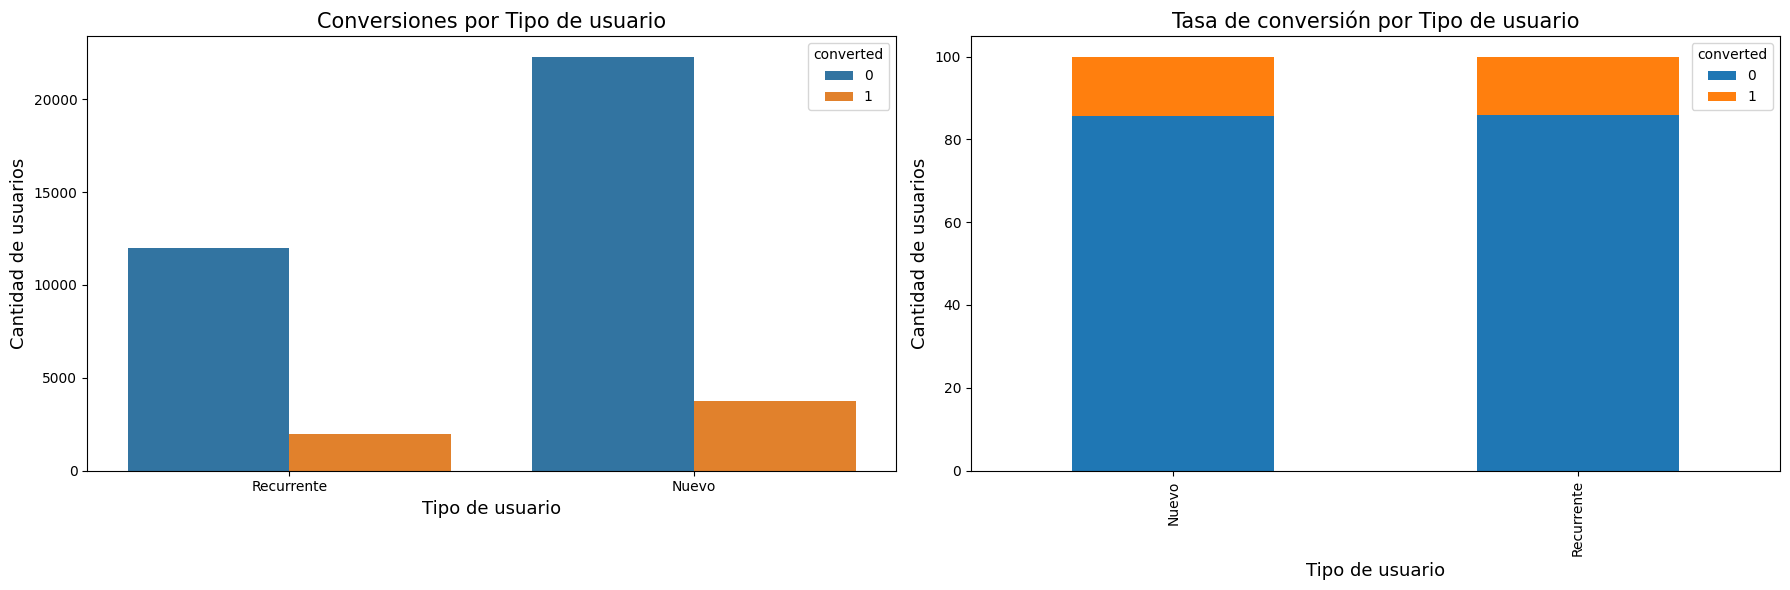

In [61]:
# Cantidad absoluta de usuarios que convirtieron y no convirtieron (Barras agrupadas)
fig, axes = plt.subplots(1, 2, figsize=(18,6))
# Barras agrupadas
sns.countplot(data=df, x='user_type', hue='converted', ax=axes[0])
axes[0].set_title("Conversiones por Tipo de usuario", fontsize=15)
axes[0].set_xlabel("Tipo de usuario", fontsize=13)
axes[0].set_ylabel("Cantidad de usuarios", fontsize=13)

# Barras apiladas
tabla_normalizada2.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Tasa de conversión por Tipo de usuario', fontsize=15)
axes[1].set_xlabel("Tipo de usuario", fontsize=13)
axes[1].set_ylabel("Cantidad de usuarios", fontsize=13)

plt.tight_layout()
plt.show()

✍️ **Comentario**: 
Como se vio anteriormente, el tipo de usuario parece no influir en la tasa de conversión, que es muy similar en ambas. Si bien se muestra que los usuarios nuevos tienen una mayor tasa de conversión, son también más frecuentes que los recurrentes y la tasa es, como se mencionó, muy similar.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El gasto promedio en la versión A, es de: 61.08
- El gasto promedio en la versión B, es de: 68.74
- **Interpretación:**
Hay una diferencia a favor de la versión B: cada usuario gasta en promedio $ 7.66 más en la versión B que en la versión A.
Parece haber tanto una evidencia estadística significativa como, probablemente, una relevancia económica.  
<br>

**Tasa de conversión:** 
- Se rechaza la hipótesis nula, que supone que ambas versiones convierten igual. Las diferencias no se derivan del azar, sino de las propias versiones. 
- La opción B tiene una tasa de conversión del 15.96%, mientras que la A presenta una tasa de conversión de 12.57%.
- **Interpretación:**
La opción B presenta una mayor tasa de conversión, por una diferencia de 3.38%. En este punto se sabe que la opción B genera más gasto promedio e incientiva mejor la conversión. 
---

#### 📊 **Segmentación por fuente de tráfico**
- Se rechaza la hipótesis nula, pues hay evidencia de asociación entre la fuente de tráfico y la conversión.
- **Interpretación:**
 Si bien existe evidencia estadística de asociación entre la fuente de tráfico y la conversión, las diferencias entre las diferentes tanasas de conversión de los canales existentes, son relativamente pequeñas, por lo que se recomienda evaluar el volumen de tráfico y el impacto absoluto de las conversiones para determinar si hay relevancia económica. 
 ---

#### 📊 **Segmentación por tipo de usuario**
- No ser encontró evidencia estadísticaente significativa de asociación entre el tipo de usuario y la conversión.
- **Interpretación:**
Las tasas de conversión son prácticamente iguales entre ambos grupos (nuevo o recurrente), lo que suguiere que el comportamiento de conversión no depende del tipo de usuario. 
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
La tasa de conversión parece no tener relación con el tipo de usuario (nuevo o recurrente) y es muy estable, siempre entre los rangos del 13 al 15%. La versión B parece dar mejores resultados, por lo que se sugiere implementar a ésta como la principal:
- Mayor tasa de conversión (+3.38 pp).
- Mayor gasto promedio por usuario convertido (+$7.66).
- Evidencia estadística sólida.
- Diferencia económicamente relevante.
- Continuar con monitore de métricas post implementación.
Parece ser más relevante el volumen que las diferencias entre fuentes, pues éstas son muy pequeñas. Se sugiere optimizar la inversión el los canales que aporten mayor volumen, como es el caso de 'Organic'. Se sugiere también revisar el ROI por canal antes de hacer redistribuciones presupuestarias.

En tanto al tipo de usuario, parece que no se derivan diferencias por ese rubro, por lo que no se recomiendan estrategias diferenciadas según el tipo de usuario, sino más bien enfocar los esfuerzos en la optimización global de la versión B. 

En resumen, la versión B muestra mejoras consistentes tanto en conversión como en gasto promedio, con evidencia estadística y probable relevancia económica. Se recomienda su implementación como versión principal, priorizando el crecimiento vía volumen de tráfico más que por micro-optimización entre canales, y manteniendo una estrategia homogénea respecto al tipo de usuario.